# Phase 1 EDA — ROGII Wellbore Geology Prediction

Predict `TVT` along the evaluation zone of horizontal wells. Inputs per well: a horizontal-well CSV 
(trajectory `MD`/`X`/`Y`/`Z`, gamma-ray `GR`, partially-known `TVT_input`, and train-only formation surface 
predictions) plus a typewell CSV (a vertical reference log: `TVT`-indexed `GR` with formation labels). 
Metric: RMSE.

**This notebook does EDA only — no modeling.** Sections:
1. File inventory (train/test/typewell pairing)
2. Schema discovery (what columns are actually there)
3. Per-well length distributions
4. Structure of `TVT_input` masking — where the eval zone sits within each well
5. Distributions of TVT, GR (lateral & typewell), missingness
6. Trajectory geometry (inclination, lateral extent)
7. Per-well visualizations of representative wells
8. Sanity checks (MD monotonicity, duplicates, file pairing, TVT-range alignment)
9. Summary of findings to inform Phase 2

Cells are organized so that, after running the **Setup** and **Inventory & summaries** sections once, 
downstream sections can be re-run independently in any order.

## 0. Setup

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

# --- Paths: notebook lives in notebooks/, data is at ../data/{train,test} ---
ROOT = Path('..').resolve()
DATA = ROOT / 'data'
TRAIN_DIR = DATA / 'train'
TEST_DIR  = DATA / 'test'

# --- Canonical column names (adjust here if schema discovery shows different names) ---
COL_MD        = 'MD'
COL_X, COL_Y, COL_Z = 'X', 'Y', 'Z'
COL_GR        = 'GR'
COL_TVT_INPUT = 'TVT_input'   # in horizontal well
COL_TVT       = 'TVT'         # in typewell
COL_FORMATION = 'formation'   # in typewell
COL_WELLNAME  = 'wellname'    # may or may not exist as a column

# Columns we expect in horizontal wells; everything else (other than wellname/row_index)
# is presumed to be a formation-surface-prediction column.
HORIZONTAL_KNOWN = {COL_MD, COL_X, COL_Y, COL_Z, COL_GR, COL_TVT_INPUT, COL_WELLNAME, 'row_index'}

print(f'Project root: {ROOT}')
print(f'Data dir:     {DATA}      exists={DATA.exists()}')
print(f'Train dir:    {TRAIN_DIR} exists={TRAIN_DIR.exists()}')
print(f'Test  dir:    {TEST_DIR}  exists={TEST_DIR.exists()}')

Project root: C:\Users\s159286\Documents\venv\ROGII-Wellbore
Data dir:     C:\Users\s159286\Documents\venv\ROGII-Wellbore\data      exists=True
Train dir:    C:\Users\s159286\Documents\venv\ROGII-Wellbore\data\train exists=True
Test  dir:    C:\Users\s159286\Documents\venv\ROGII-Wellbore\data\test  exists=True


## 1. File inventory

In [2]:
HW_RE  = re.compile(r'^(.+)__horizontal_well\.csv$')
TW_RE  = re.compile(r'^(.+)__typewell\.csv$')
PNG_RE = re.compile(r'^(.+)\.png$')

def scan_dir(d: Path) -> tuple[pd.DataFrame, list[str]]:
    """Returns (inventory_df, unmatched_filenames)."""
    if not d.exists():
        return pd.DataFrame(columns=['well','horizontal_well','typewell','png']), []
    by_well: dict[str, dict] = {}
    unmatched = []
    for f in sorted(d.iterdir()):
        if not f.is_file():
            continue
        for kind, rx in [('hw', HW_RE), ('tw', TW_RE), ('png', PNG_RE)]:
            m = rx.match(f.name)
            if m:
                by_well.setdefault(m.group(1), {})[kind] = f.name
                break
        else:
            unmatched.append(f.name)
    rows = [{'well': w,
             'horizontal_well': k.get('hw'),
             'typewell':        k.get('tw'),
             'png':             k.get('png')}
            for w, k in by_well.items()]
    inv = pd.DataFrame(rows).sort_values('well').reset_index(drop=True)
    return inv, unmatched

train_inv, train_extra = scan_dir(TRAIN_DIR)
test_inv,  test_extra  = scan_dir(TEST_DIR)

def report(label, inv, extra):
    print(f'{label}: {len(inv)} unique well names')
    print(f"  with horizontal CSV: {inv['horizontal_well'].notna().sum()}")
    print(f"  with typewell CSV:   {inv['typewell'].notna().sum()}")
    print(f"  with PNG:            {inv['png'].notna().sum()}")
    miss_hw = inv[inv['horizontal_well'].isna()]['well'].tolist()
    miss_tw = inv[inv['typewell'].isna()]['well'].tolist()
    if miss_hw: print(f'  wells missing horizontal_well CSV: {miss_hw}')
    if miss_tw: print(f'  wells missing typewell CSV:        {miss_tw}')
    if extra:   print(f'  unmatched files in dir ({len(extra)}): {extra[:10]}{"..." if len(extra)>10 else ""}')
    print()

report('TRAIN', train_inv, train_extra)
report('TEST ', test_inv,  test_extra)

# Look for any extra files at the data-dir level (e.g. sample_submission.csv)
print('Files directly under data/:')
for f in sorted(DATA.glob('*')):
    if f.is_file():
        print(f'  {f.name}')

train_inv.head()

TRAIN: 773 unique well names
  with horizontal CSV: 773
  with typewell CSV:   773
  with PNG:            773

TEST : 3 unique well names
  with horizontal CSV: 3
  with typewell CSV:   3
  with PNG:            0

Files directly under data/:
  AI_wellbore_geology_prediction_task_en.pptx
  sample_submission.csv


,well,horizontal_well,typewell,png
0,000d7d20,000d7d20__horizontal_well.csv,000d7d20__typewell.csv,000d7d20.png
1,00bbac68,00bbac68__horizontal_well.csv,00bbac68__typewell.csv,00bbac68.png
2,00e12e8b,00e12e8b__horizontal_well.csv,00e12e8b__typewell.csv,00e12e8b.png
3,015fe0d2,015fe0d2__horizontal_well.csv,015fe0d2__typewell.csv,015fe0d2.png
4,01869cd4,01869cd4__horizontal_well.csv,01869cd4__typewell.csv,01869cd4.png


## 2. Schema discovery

Open one example file from each split and report the columns. The constants block in **Setup** 
should match what we see here; if not, edit those constants and re-run.

In [3]:
def peek(path: Path, n=3):
    df = pd.read_csv(path)
    print(f"\n{'='*70}\n{path.name}  shape={df.shape}\n{'='*70}")
    print('dtypes:')
    print(df.dtypes.to_string())
    print(f'\nhead({n}):')
    print(df.head(n).to_string())
    return df

ex_train_well = train_inv.dropna(subset=['horizontal_well','typewell']).iloc[0]['well']
print(f'Example TRAIN well: {ex_train_well}')

ex_hw = peek(TRAIN_DIR / f'{ex_train_well}__horizontal_well.csv')
ex_tw = peek(TRAIN_DIR / f'{ex_train_well}__typewell.csv')

if len(test_inv):
    ex_test_well = test_inv.dropna(subset=['horizontal_well']).iloc[0]['well']
    print(f'\nExample TEST well: {ex_test_well}')
    ex_hw_test = peek(TEST_DIR / f'{ex_test_well}__horizontal_well.csv')
else:
    ex_hw_test = pd.DataFrame()

# Compare train vs test horizontal-well schemas
if len(ex_hw_test):
    train_cols = set(ex_hw.columns)
    test_cols  = set(ex_hw_test.columns)
    print('\n-- Schema diff: horizontal-well train vs test --')
    print(f'  train-only columns ({len(train_cols - test_cols)}): {sorted(train_cols - test_cols)}')
    print(f'  test-only columns  ({len(test_cols - train_cols)}): {sorted(test_cols - train_cols)}')
    print(f'  shared columns     ({len(train_cols & test_cols)}): {sorted(train_cols & test_cols)}')

# Identify likely surface-prediction columns in train
surface_cols = [c for c in ex_hw.columns if c not in HORIZONTAL_KNOWN]
print(f'\nLikely surface-prediction columns in train horizontal ({len(surface_cols)}):')
print(f'  {surface_cols}')

Example TRAIN well: 000d7d20

000d7d20__horizontal_well.csv  shape=(5278, 13)
dtypes:
MD           float64
X            float64
Y            float64
Z            float64
ANCC         float64
ASTNU        float64
ASTNL        float64
EGFDU        float64
EGFDL        float64
BUDA         float64
TVT          float64
GR           float64
TVT_input    float64

head(3):
        MD           X           Y        Z     ANCC    ASTNU    ASTNL    EGFDU    EGFDL     BUDA       TVT          GR  TVT_input
0  11467.0  2983525.16  1069022.09 -9258.57 -9395.81 -9569.86 -9597.64 -9670.99 -9705.96 -9846.35  11236.02  115.692586   11236.02
1  11468.0  2983525.18  1069022.30 -9259.55 -9395.75 -9569.80 -9597.58 -9670.93 -9705.90 -9846.29  11237.05  115.584293   11237.05
2  11469.0  2983525.20  1069022.52 -9260.52 -9395.69 -9569.74 -9597.52 -9670.87 -9705.84 -9846.23  11238.09  135.446960   11238.09

000d7d20__typewell.csv  shape=(1296, 3)
dtypes:
TVT        float64
GR         float64
Geology        str



## 3. Per-well summaries

Build a per-well summary DataFrame for both horizontal and typewell files. Used by all downstream sections.

In [4]:
def summarize_horizontal(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    out: dict = {'n_rows': n, 'n_cols': df.shape[1]}
    if COL_TVT_INPUT in df.columns:
        mask = df[COL_TVT_INPUT].isna().values
        out['n_eval'] = int(mask.sum())
        out['frac_eval'] = float(mask.mean()) if n else np.nan
        if mask.any():
            idx = np.where(mask)[0]
            out['eval_start_idx'] = int(idx[0])
            out['eval_end_idx']   = int(idx[-1])
            out['eval_contiguous'] = bool((idx[-1] - idx[0] + 1) == len(idx))
            out['eval_at_tail']    = bool(idx[-1] == n - 1)
            out['eval_at_head']    = bool(idx[0] == 0)
            # Number of contiguous masked runs (>1 = non-contiguous)
            out['n_eval_runs'] = int((np.diff(idx) > 1).sum() + 1)
        else:
            out.update({'eval_start_idx': -1, 'eval_end_idx': -1,
                        'eval_contiguous': True, 'eval_at_tail': False,
                        'eval_at_head': False, 'n_eval_runs': 0})
    if COL_MD in df.columns:
        md_vals = df[COL_MD].values
        out['md_min']    = float(np.nanmin(md_vals))
        out['md_max']    = float(np.nanmax(md_vals))
        out['md_range']  = out['md_max'] - out['md_min']
        diffs = np.diff(md_vals)
        diffs = diffs[~np.isnan(diffs)]
        out['md_monotonic_inc'] = bool(len(diffs) and (diffs > 0).all())
        out['md_step_median']   = float(np.median(diffs)) if len(diffs) else np.nan
        out['md_step_min']      = float(np.min(diffs)) if len(diffs) else np.nan
    if COL_GR in df.columns:
        gr = df[COL_GR]
        out['gr_mean']     = float(gr.mean())
        out['gr_std']      = float(gr.std())
        out['gr_nan_frac'] = float(gr.isna().mean())
    return out

def summarize_typewell(path: Path) -> dict:
    df = pd.read_csv(path)
    out: dict = {'n_rows': len(df), 'n_cols': df.shape[1]}
    if COL_TVT in df.columns:
        out['tvt_min']   = float(df[COL_TVT].min())
        out['tvt_max']   = float(df[COL_TVT].max())
        out['tvt_range'] = out['tvt_max'] - out['tvt_min']
        d = np.diff(df[COL_TVT].values)
        d = d[~np.isnan(d)]
        out['tvt_step_median'] = float(np.median(d)) if len(d) else np.nan
    if COL_GR in df.columns:
        out['gr_mean']     = float(df[COL_GR].mean())
        out['gr_std']      = float(df[COL_GR].std())
        out['gr_nan_frac'] = float(df[COL_GR].isna().mean())
    if COL_FORMATION in df.columns:
        out['n_formations'] = int(df[COL_FORMATION].nunique(dropna=True))
    return out

def build_summary(inv: pd.DataFrame, base: Path, label: str) -> pd.DataFrame:
    rows = []
    for _, r in inv.iterrows():
        if pd.notna(r['horizontal_well']):
            d = summarize_horizontal(base / r['horizontal_well'])
            d.update({'well': r['well'], 'split': label, 'kind': 'horizontal'})
            rows.append(d)
        if pd.notna(r['typewell']):
            d = summarize_typewell(base / r['typewell'])
            d.update({'well': r['well'], 'split': label, 'kind': 'typewell'})
            rows.append(d)
    return pd.DataFrame(rows)

train_summary = build_summary(train_inv, TRAIN_DIR, 'train')
test_summary  = build_summary(test_inv,  TEST_DIR,  'test')
summary = pd.concat([train_summary, test_summary], ignore_index=True)

train_h = summary.query("split == 'train' and kind == 'horizontal'").reset_index(drop=True)
test_h  = summary.query("split == 'test'  and kind == 'horizontal'").reset_index(drop=True)
train_t = summary.query("split == 'train' and kind == 'typewell'").reset_index(drop=True)
test_t  = summary.query("split == 'test'  and kind == 'typewell'").reset_index(drop=True)

print(f'train horizontal: {len(train_h)} | test horizontal: {len(test_h)}')
print(f'train typewell:   {len(train_t)} | test typewell:   {len(test_t)}')
summary.head()

train horizontal: 773 | test horizontal: 3
train typewell:   773 | test typewell:   3


,n_rows,n_cols,n_eval,frac_eval,eval_start_idx,eval_end_idx,eval_contiguous,eval_at_tail,eval_at_head,n_eval_runs,md_min,md_max,md_range,md_monotonic_inc,md_step_median,md_step_min,gr_mean,gr_std,gr_nan_frac,well,split,kind,tvt_min,tvt_max,tvt_range,tvt_step_median
0,5278,13,3836.0,0.726790,1442.0,5277.0,True,True,False,1.0,11467.0,16744.0,5277.0,True,1.0,1.0,94.436961,18.627493,0.427814,000d7d20,train,horizontal,NaN,NaN,NaN,NaN
1,1296,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.257639,26.251321,0.000000,000d7d20,train,typewell,11223.95,11871.45,647.5,0.5
2,7559,13,6014.0,0.795608,1545.0,7558.0,True,True,False,1.0,11578.0,19136.0,7558.0,True,1.0,1.0,88.255106,17.157431,0.124620,00bbac68,train,horizontal,NaN,NaN,NaN,NaN
3,1946,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.344173,27.661227,0.000000,00bbac68,train,typewell,11394.45,12366.95,972.5,0.5
4,6384,13,4301.0,0.673716,2083.0,6383.0,True,True,False,1.0,10456.0,16839.0,6383.0,True,1.0,1.0,53.642421,33.321410,0.091479,00e12e8b,train,horizontal,NaN,NaN,NaN,NaN


## 4. Length distributions

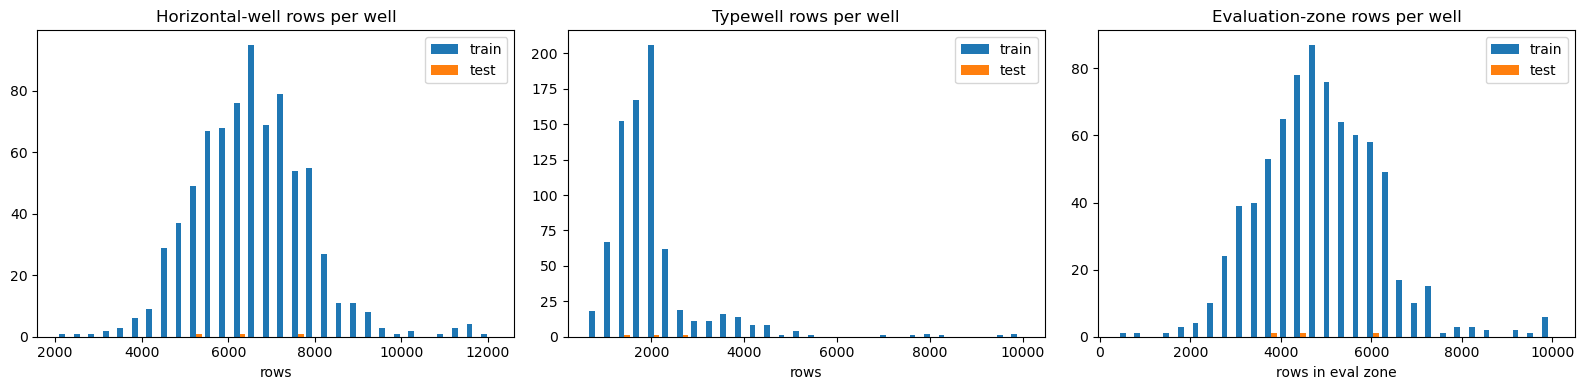

Horizontal-well rows:
  train: n=773, median=6576, IQR=[5706, 7388], min=2058, max=12141
  test : n=3, median=6384, IQR=[5831, 6972], min=5278, max=7559
Typewell rows:
  train: n=773, median=1874, IQR=[1498, 2158], min=636, max=10043
  test : n=3, median=1946, IQR=[1621, 2251], min=1296, max=2556
Eval-zone rows:
  train: n=773, median=4840, IQR=[4044, 5694], min=407, max=10052
  test : n=3, median=4301, IQR=[4068, 5158], min=3836, max=6014
Eval-zone fraction of well:
  train (%): n=773, median=74, IQR=[70, 78], min=20, max=88
  test  (%): n=3, median=73, IQR=[70, 76], min=67, max=80


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist([train_h['n_rows'], test_h['n_rows']], bins=30, label=['train','test'])
axes[0].set_title('Horizontal-well rows per well')
axes[0].set_xlabel('rows'); axes[0].legend()

tw_data = [s['n_rows'] for s in (train_t, test_t) if len(s)]
tw_lbl  = [l for l, s in zip(['train','test'], (train_t, test_t)) if len(s)]
if tw_data:
    axes[1].hist(tw_data, bins=30, label=tw_lbl)
axes[1].set_title('Typewell rows per well')
axes[1].set_xlabel('rows'); axes[1].legend()

axes[2].hist([train_h['n_eval'].dropna(), test_h['n_eval'].dropna()],
             bins=30, label=['train','test'])
axes[2].set_title('Evaluation-zone rows per well')
axes[2].set_xlabel('rows in eval zone'); axes[2].legend()

plt.tight_layout(); plt.show()

def stats(s, name):
    if len(s) == 0: return f'  {name}: (empty)'
    return f'  {name}: n={len(s)}, median={s.median():.0f}, IQR=[{s.quantile(.25):.0f}, {s.quantile(.75):.0f}], min={s.min():.0f}, max={s.max():.0f}'

print('Horizontal-well rows:')
print(stats(train_h['n_rows'], 'train'))
print(stats(test_h['n_rows'],  'test '))
print('Typewell rows:')
print(stats(train_t['n_rows'], 'train'))
print(stats(test_t['n_rows'],  'test '))
print('Eval-zone rows:')
print(stats(train_h['n_eval'], 'train'))
print(stats(test_h['n_eval'],  'test '))
print('Eval-zone fraction of well:')
print(stats(train_h['frac_eval'].mul(100), 'train (%)'))
print(stats(test_h['frac_eval'].mul(100),  'test  (%)'))

## 5. Structure of `TVT_input` masking

Where does the eval zone sit within each well? Always tail? Always contiguous? What fraction is masked?

In [6]:
hsum = pd.concat([train_h, test_h], ignore_index=True)

print('Eval zone always contiguous?      ', bool(hsum['eval_contiguous'].all()))
print('Eval zone always at the tail?     ', bool(hsum['eval_at_tail'].all()))
print('Eval zone ever at the head (idx 0)?', bool(hsum['eval_at_head'].any()))
print('Max number of disjoint eval runs in a single well:', int(hsum['n_eval_runs'].max()))
print()

# Position breakdown
pos = pd.DataFrame({
    'tail_only':    hsum['eval_at_tail'] & ~hsum['eval_at_head'],
    'head_only':    hsum['eval_at_head'] & ~hsum['eval_at_tail'],
    'head_and_tail':hsum['eval_at_head'] &  hsum['eval_at_tail'],
    'interior':    ~hsum['eval_at_head'] & ~hsum['eval_at_tail'] & (hsum['n_eval'] > 0),
    'no_eval':      hsum['n_eval'] == 0,
}).sum().to_frame('n_wells')
pos['pct'] = (pos['n_wells'] / len(hsum) * 100).round(1)
print('Eval-zone position across all horizontal wells (train+test):')
print(pos)
print()
print('Eval-zone fraction summary:')
print(hsum['frac_eval'].describe().round(3))

Eval zone always contiguous?       True
Eval zone always at the tail?      True
Eval zone ever at the head (idx 0)? False
Max number of disjoint eval runs in a single well: 1

Eval-zone position across all horizontal wells (train+test):
               n_wells    pct
tail_only          776  100.0
head_only            0    0.0
head_and_tail        0    0.0
interior           776  100.0
no_eval              0    0.0

Eval-zone fraction summary:
count    776.000
mean       0.733
std        0.064
min        0.198
25%        0.700
50%        0.740
75%        0.776
max        0.875
Name: frac_eval, dtype: float64


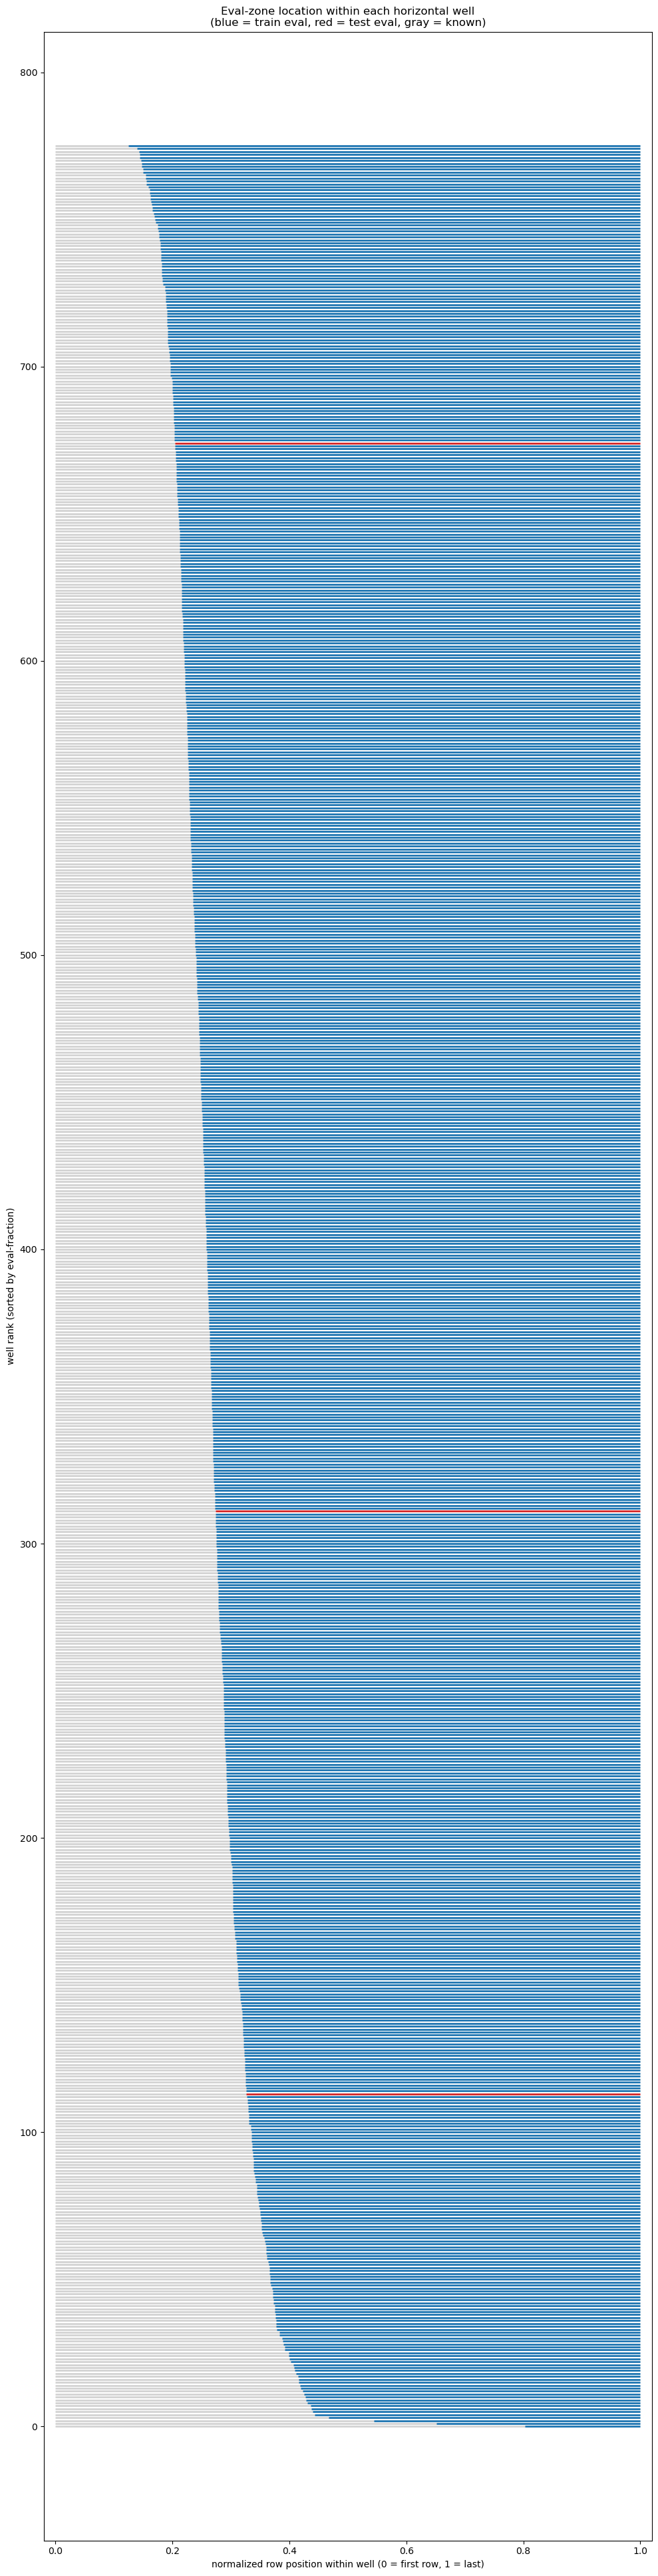

In [7]:
# Visualize eval-zone position per well: each row is one well, x-axis = normalized position 0..1.
# Gray = known TVT_input, blue/red = eval zone (blue=train, red=test). Sorted by frac_eval.
hsum_sorted = hsum.sort_values('frac_eval').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, max(5, len(hsum_sorted) * 0.05)))
for i, r in hsum_sorted.iterrows():
    n = r['n_rows']
    if not n or pd.isna(r['eval_start_idx']) or r['eval_start_idx'] < 0:
        ax.hlines(i, 0, 1, color='lightgray', linewidth=2)
        continue
    ax.hlines(i, 0, 1, color='lightgray', linewidth=2)
    s = r['eval_start_idx'] / n
    e = (r['eval_end_idx'] + 1) / n
    color = 'C0' if r['split'] == 'train' else 'C3'
    ax.hlines(i, s, e, color=color, linewidth=2)
ax.set_xlabel('normalized row position within well (0 = first row, 1 = last)')
ax.set_ylabel('well rank (sorted by eval-fraction)')
ax.set_title('Eval-zone location within each horizontal well\n(blue = train eval, red = test eval, gray = known)')
ax.set_xlim(-0.02, 1.02)
plt.tight_layout(); plt.show()

## 6. Distributions of TVT, GR, and missingness

In [8]:
# Pool relevant columns across wells (read once into memory).
def pool(inv: pd.DataFrame, base: Path, file_col: str, cols: list[str]) -> pd.DataFrame:
    frames = []
    for _, r in inv.iterrows():
        if pd.isna(r[file_col]): continue
        df = pd.read_csv(base / r[file_col])
        keep = [c for c in cols if c in df.columns]
        if not keep: continue
        frames.append(df[keep].assign(well=r['well']))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

lat_train = pool(train_inv, TRAIN_DIR, 'horizontal_well', [COL_GR, COL_TVT_INPUT, COL_MD])
lat_test  = pool(test_inv,  TEST_DIR,  'horizontal_well', [COL_GR, COL_TVT_INPUT, COL_MD])
tw_train  = pool(train_inv, TRAIN_DIR, 'typewell',        [COL_GR, COL_TVT, COL_FORMATION])
tw_test   = pool(test_inv,  TEST_DIR,  'typewell',        [COL_GR, COL_TVT, COL_FORMATION])

print(f'Pooled lateral train rows: {len(lat_train):,} | test rows: {len(lat_test):,}')
print(f'Pooled typewell train rows: {len(tw_train):,} | test rows: {len(tw_test):,}')

Pooled lateral train rows: 5,092,255 | test rows: 19,221
Pooled typewell train rows: 1,567,045 | test rows: 5,798


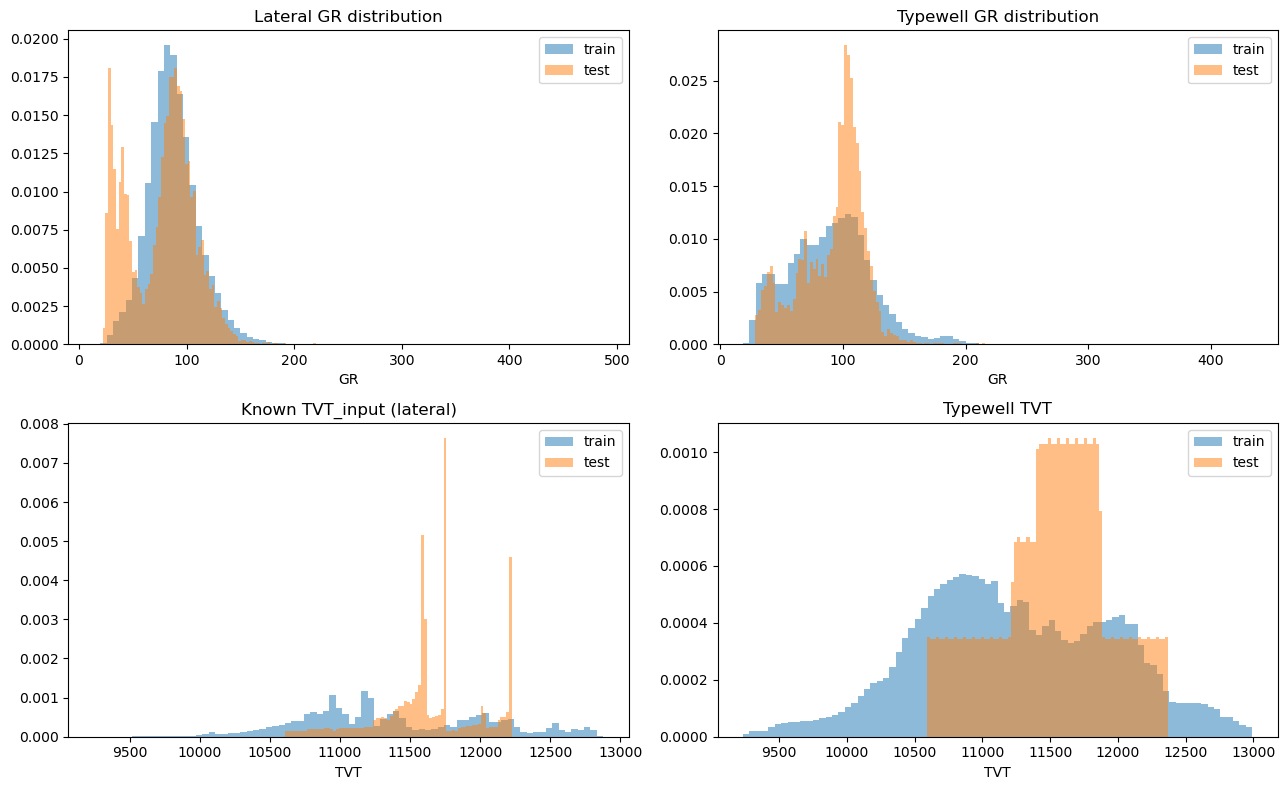

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

if COL_GR in lat_train and COL_GR in lat_test:
    axes[0,0].hist(lat_train[COL_GR].dropna(), bins=80, alpha=0.5, label='train', density=True)
    axes[0,0].hist(lat_test[COL_GR].dropna(),  bins=80, alpha=0.5, label='test',  density=True)
axes[0,0].set_title('Lateral GR distribution'); axes[0,0].set_xlabel('GR'); axes[0,0].legend()

if COL_GR in tw_train and COL_GR in tw_test:
    axes[0,1].hist(tw_train[COL_GR].dropna(), bins=80, alpha=0.5, label='train', density=True)
    axes[0,1].hist(tw_test[COL_GR].dropna(),  bins=80, alpha=0.5, label='test',  density=True)
axes[0,1].set_title('Typewell GR distribution'); axes[0,1].set_xlabel('GR'); axes[0,1].legend()

if COL_TVT_INPUT in lat_train and COL_TVT_INPUT in lat_test:
    axes[1,0].hist(lat_train[COL_TVT_INPUT].dropna(), bins=80, alpha=0.5, label='train', density=True)
    axes[1,0].hist(lat_test[COL_TVT_INPUT].dropna(),  bins=80, alpha=0.5, label='test',  density=True)
axes[1,0].set_title('Known TVT_input (lateral)'); axes[1,0].set_xlabel('TVT'); axes[1,0].legend()

if COL_TVT in tw_train and COL_TVT in tw_test:
    axes[1,1].hist(tw_train[COL_TVT].dropna(), bins=80, alpha=0.5, label='train', density=True)
    axes[1,1].hist(tw_test[COL_TVT].dropna(),  bins=80, alpha=0.5, label='test',  density=True)
axes[1,1].set_title('Typewell TVT'); axes[1,1].set_xlabel('TVT'); axes[1,1].legend()

plt.tight_layout(); plt.show()

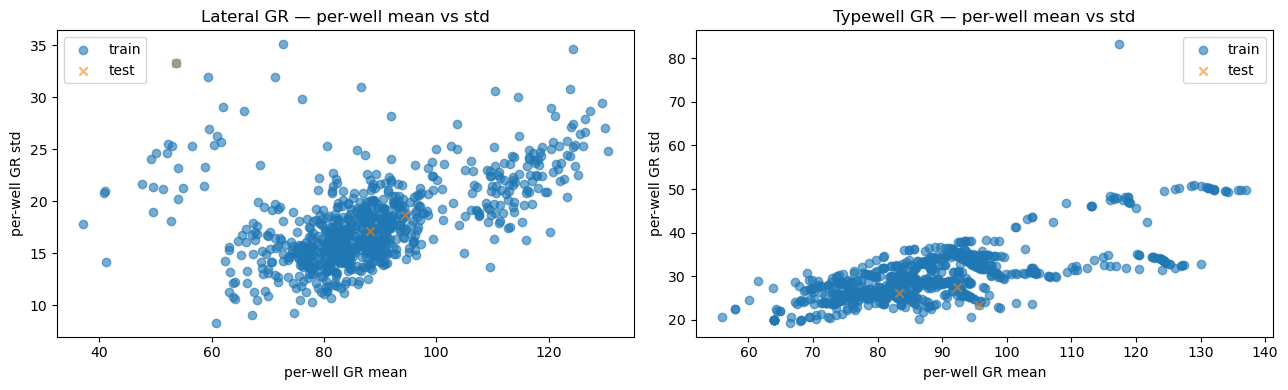

In [10]:
# Per-well GR scale: mean vs std, train vs test. Big spread ⇒ wells need normalization for cross-well models.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(train_h['gr_mean'], train_h['gr_std'], alpha=0.6, label='train')
axes[0].scatter(test_h['gr_mean'],  test_h['gr_std'],  alpha=0.6, label='test', marker='x')
axes[0].set_xlabel('per-well GR mean'); axes[0].set_ylabel('per-well GR std')
axes[0].set_title('Lateral GR — per-well mean vs std'); axes[0].legend()

axes[1].scatter(train_t['gr_mean'], train_t['gr_std'], alpha=0.6, label='train')
axes[1].scatter(test_t['gr_mean'],  test_t['gr_std'],  alpha=0.6, label='test', marker='x')
axes[1].set_xlabel('per-well GR mean'); axes[1].set_ylabel('per-well GR std')
axes[1].set_title('Typewell GR — per-well mean vs std'); axes[1].legend()
plt.tight_layout(); plt.show()

In [11]:
# Missingness aggregated across wells.
def aggregate_missing(inv: pd.DataFrame, base: Path, file_col: str) -> pd.DataFrame:
    rows = []
    for _, r in inv.iterrows():
        if pd.isna(r[file_col]): continue
        df = pd.read_csv(base / r[file_col])
        rows.append(df.isna().mean().rename(r['well']))
    return pd.DataFrame(rows)

miss_train_h = aggregate_missing(train_inv, TRAIN_DIR, 'horizontal_well')
miss_test_h  = aggregate_missing(test_inv,  TEST_DIR,  'horizontal_well')
miss_train_t = aggregate_missing(train_inv, TRAIN_DIR, 'typewell')
miss_test_t  = aggregate_missing(test_inv,  TEST_DIR,  'typewell')

def show_miss(df, name):
    if not len(df): print(f'{name}: (empty)'); return
    s = df.mean().sort_values(ascending=False).round(3)
    print(f'{name} — mean NaN fraction per column across wells (>0 only):')
    print(s[s > 0].to_string() if (s > 0).any() else '  (all columns fully populated)')
    print()

show_miss(miss_train_h, 'TRAIN horizontal')
show_miss(miss_test_h,  'TEST  horizontal')
show_miss(miss_train_t, 'TRAIN typewell  ')
show_miss(miss_test_t,  'TEST  typewell  ')

TRAIN horizontal — mean NaN fraction per column across wells (>0 only):
TVT_input    0.733
GR           0.294
ANCC         0.009
EGFDL        0.001

TEST  horizontal — mean NaN fraction per column across wells (>0 only):
TVT_input    0.732
GR           0.215

TRAIN typewell   — mean NaN fraction per column across wells (>0 only):
Geology    0.306

TEST  typewell   — mean NaN fraction per column across wells (>0 only):
  (all columns fully populated)



## 7. Trajectory geometry

How inclined are the wells? (90° from vertical = truly horizontal.) Are eval zones reliably horizontal? 
How wide is the lateral spread vs vertical extent?

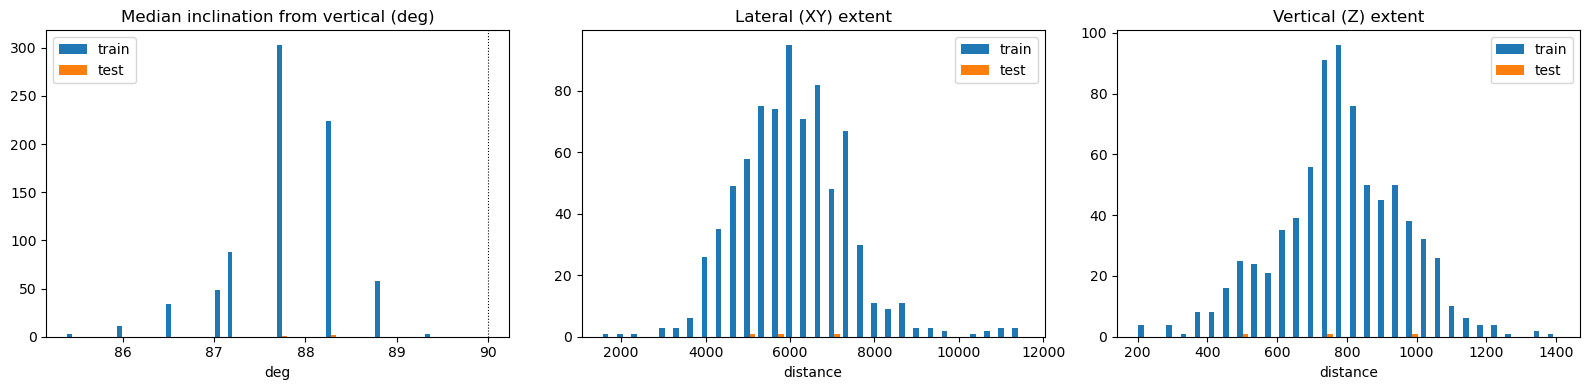

Inclination summary (degrees from vertical; ~90° = horizontal):
       incl_p50  incl_p95  incl_known_p50  incl_eval_p50  incl_eval_p95
split                                                                  
test       88.3      89.4            61.5           88.3           90.0
train      87.7      89.4            70.7           88.3           89.4

Extents (median per split):
       xy_extent  z_extent
split                     
test      5749.0     746.2
train     6085.2     787.3


In [12]:
def trajectory_features(path: Path) -> dict:
    df = pd.read_csv(path)
    out = {}
    if not all(c in df.columns for c in [COL_X, COL_Y, COL_Z, COL_MD]):
        return out
    x, y, z = df[COL_X].values, df[COL_Y].values, df[COL_Z].values
    out['xy_extent'] = float(np.hypot(x.max()-x.min(), y.max()-y.min()))
    out['z_extent']  = float(z.max() - z.min())
    dx, dy, dz = np.diff(x), np.diff(y), np.diff(z)
    dxy = np.hypot(dx, dy)
    # Inclination from vertical: arctan2(horizontal_step, |vertical_step|). 90° = horizontal.
    incl = np.degrees(np.arctan2(dxy, np.abs(dz) + 1e-9))
    if len(incl):
        out['incl_p50'] = float(np.percentile(incl, 50))
        out['incl_p95'] = float(np.percentile(incl, 95))
    if COL_TVT_INPUT in df.columns:
        m = df[COL_TVT_INPUT].isna().values
        # A trajectory step is 'in eval' if either of its endpoints is in the eval zone.
        m_step = m[:-1] | m[1:]
        if m_step.any():
            out['incl_eval_p50'] = float(np.percentile(incl[m_step], 50))
            out['incl_eval_p95'] = float(np.percentile(incl[m_step], 95))
        m_known_step = (~m[:-1]) & (~m[1:])
        if m_known_step.any():
            out['incl_known_p50'] = float(np.percentile(incl[m_known_step], 50))
    return out

def collect_traj(inv: pd.DataFrame, base: Path, label: str) -> pd.DataFrame:
    rows = []
    for _, r in inv.iterrows():
        if pd.isna(r['horizontal_well']): continue
        d = trajectory_features(base / r['horizontal_well'])
        d['well'] = r['well']; d['split'] = label
        rows.append(d)
    return pd.DataFrame(rows)

traj = pd.concat([collect_traj(train_inv, TRAIN_DIR, 'train'),
                   collect_traj(test_inv,  TEST_DIR,  'test')], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in [
    (axes[0], 'incl_p50', 'Median inclination from vertical (deg)'),
    (axes[1], 'xy_extent', 'Lateral (XY) extent'),
    (axes[2], 'z_extent',  'Vertical (Z) extent'),
]:
    data = [traj.query("split=='train'")[col].dropna(),
            traj.query("split=='test' ")[col].dropna()]
    ax.hist(data, bins=30, label=['train','test'])
    ax.set_title(title); ax.legend()
axes[0].axvline(90, color='k', ls=':', lw=0.8)  # horizontal reference
axes[0].set_xlabel('deg'); axes[1].set_xlabel('distance'); axes[2].set_xlabel('distance')
plt.tight_layout(); plt.show()

print('Inclination summary (degrees from vertical; ~90° = horizontal):')
cols_to_show = [c for c in ['incl_p50','incl_p95','incl_known_p50','incl_eval_p50','incl_eval_p95'] if c in traj.columns]
print(traj.groupby('split')[cols_to_show].median().round(1))
print()
print('Extents (median per split):')
print(traj.groupby('split')[['xy_extent','z_extent']].median().round(1))

## 8. Per-well visualizations

Lateral panel: GR vs MD with `TVT_input` overlaid (red), eval zone shaded. 
Typewell panel: GR vs TVT (vertical, geological orientation). 
TVT axes are aligned across the two panels to make visual correlation possible.

Representative wells:
  train/12203f2a
  train/eb06a4e7
  train/84633df4
  train/99529c45
  train/9a8ae0d6
  test/00e12e8b
  test/000d7d20
  test/00bbac68


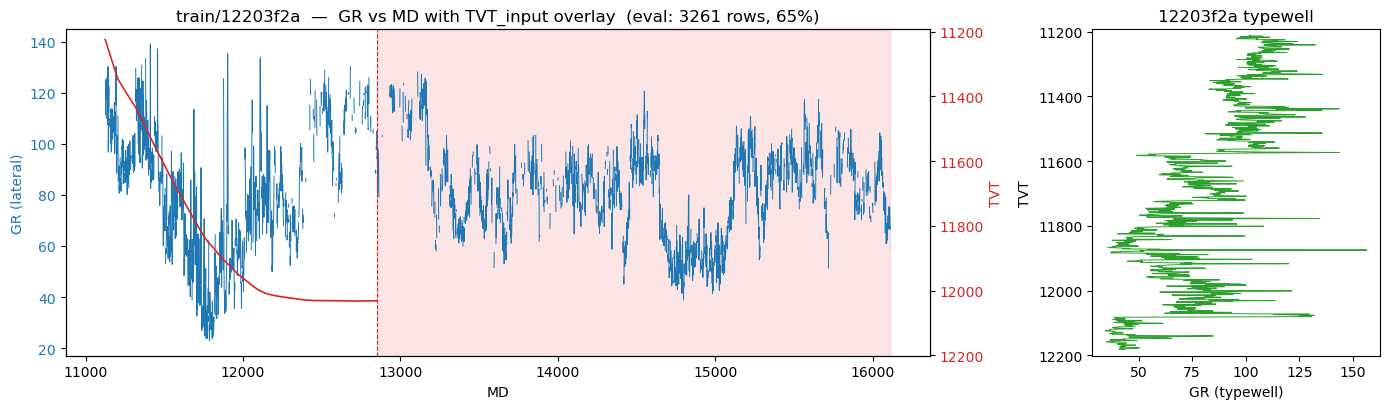

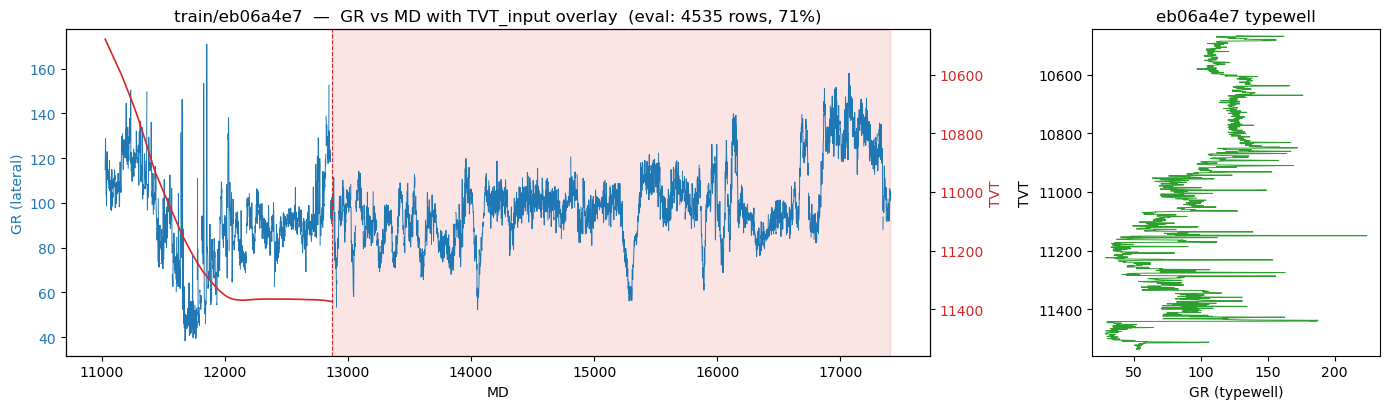

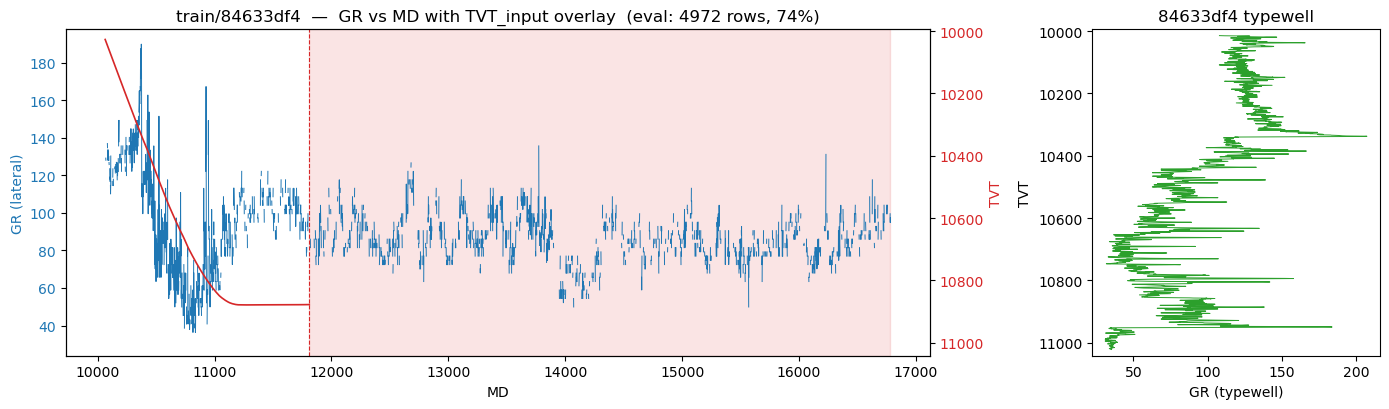

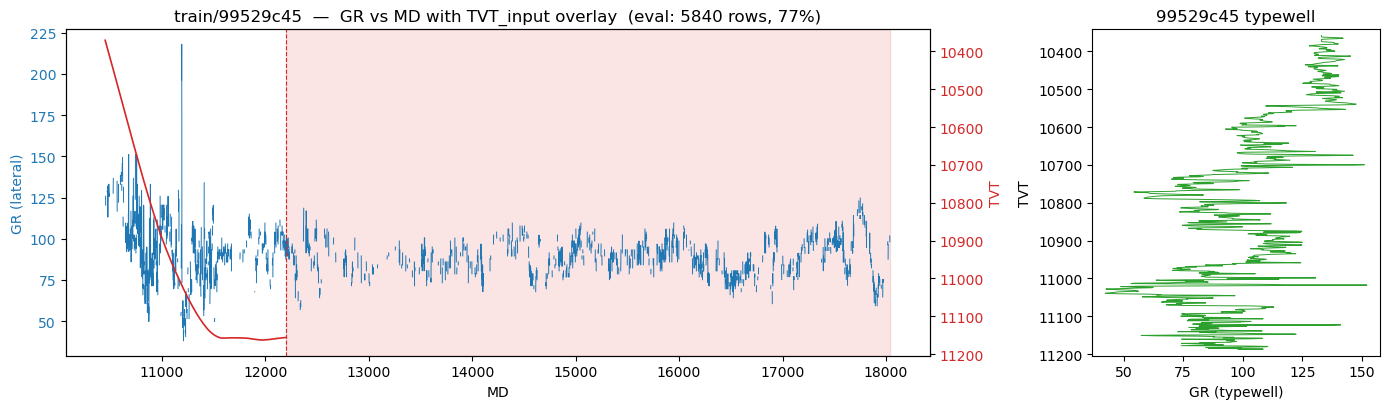

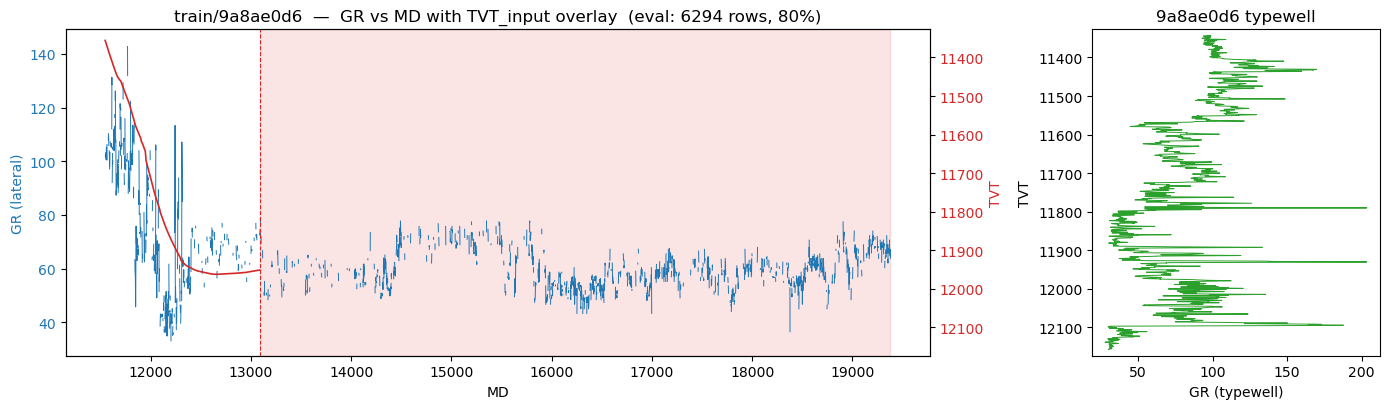

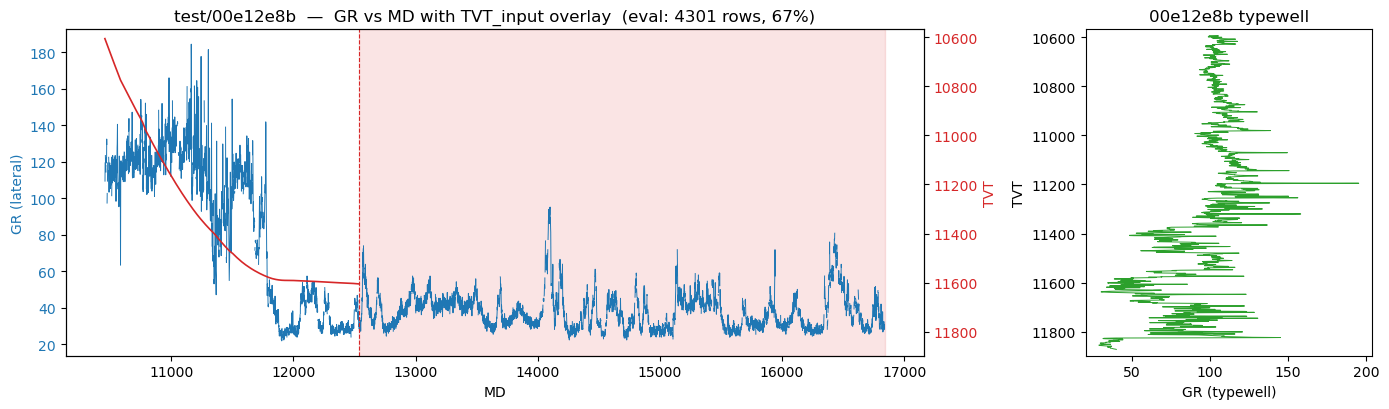

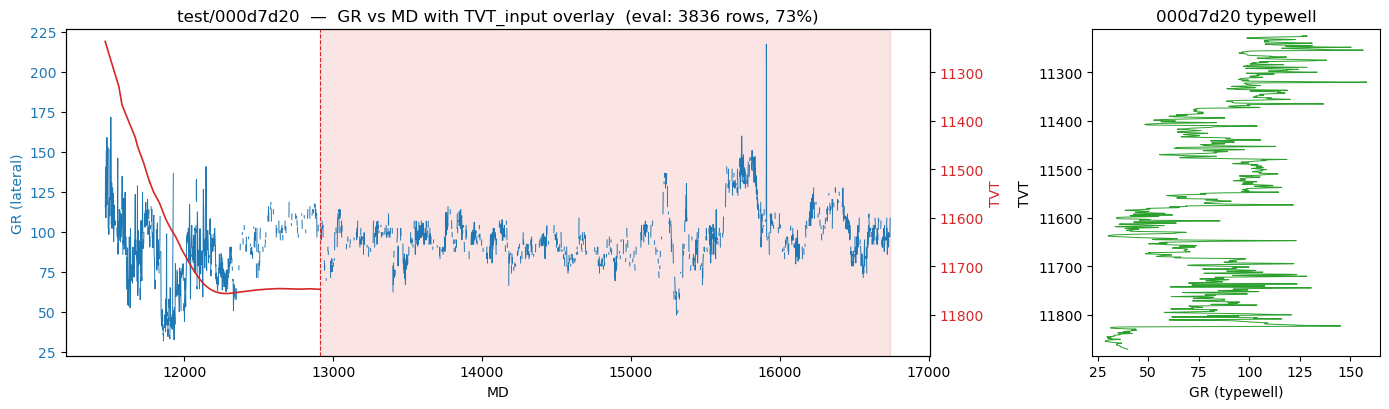

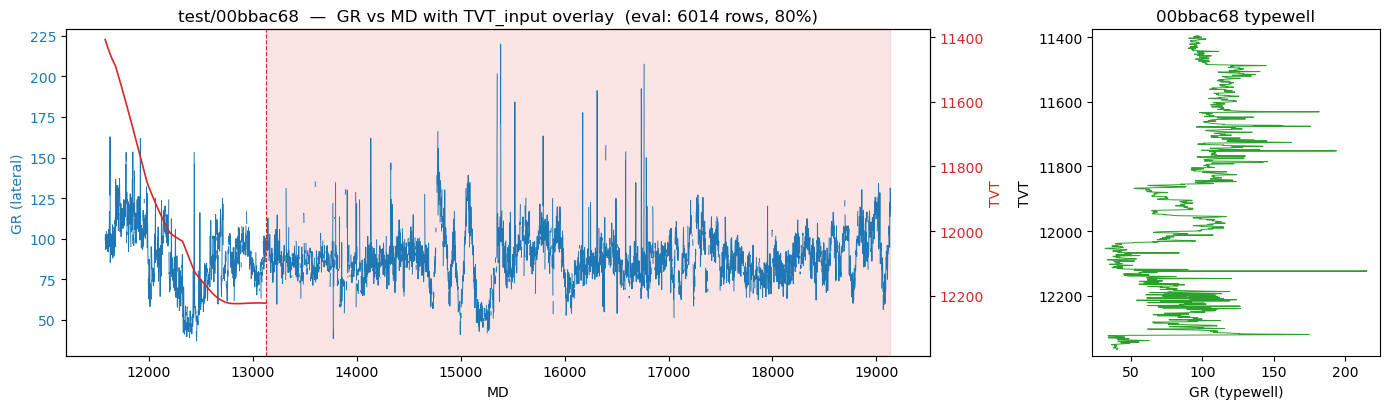

In [13]:
def plot_well(well: str, split: str):
    base = TRAIN_DIR if split == 'train' else TEST_DIR
    hw = pd.read_csv(base / f'{well}__horizontal_well.csv')
    tw_path = base / f'{well}__typewell.csv'
    tw = pd.read_csv(tw_path) if tw_path.exists() else pd.DataFrame()

    fig, (ax_lat, ax_tw) = plt.subplots(
        1, 2, figsize=(14, 4.2), gridspec_kw={'width_ratios':[3,1]})

    md = hw[COL_MD].values if COL_MD in hw.columns else np.arange(len(hw))
    gr = hw[COL_GR].values if COL_GR in hw.columns else None
    tvt_in = hw[COL_TVT_INPUT].values if COL_TVT_INPUT in hw.columns else None
    eval_mask = np.isnan(tvt_in) if tvt_in is not None else np.zeros(len(hw), dtype=bool)

    # Lateral GR on left axis
    if gr is not None:
        ax_lat.plot(md, gr, color='C0', lw=0.7)
    ax_lat.set_xlabel('MD'); ax_lat.set_ylabel('GR (lateral)', color='C0')
    ax_lat.tick_params(axis='y', labelcolor='C0')

    # TVT_input on right axis
    ax2 = ax_lat.twinx()
    if tvt_in is not None and (~eval_mask).any():
        ax2.plot(md[~eval_mask], tvt_in[~eval_mask], color='C3', lw=1.2)
    ax2.set_ylabel('TVT', color='C3'); ax2.tick_params(axis='y', labelcolor='C3')

    # Shade eval zone and mark the boundary
    if eval_mask.any():
        idx = np.where(eval_mask)[0]
        ax_lat.axvspan(md[idx[0]], md[idx[-1]], alpha=0.12, color='C3')
        ax_lat.axvline(md[idx[0]], color='C3', ls='--', lw=0.8)
        if idx[-1] < len(md) - 1:
            ax_lat.axvline(md[idx[-1]], color='C3', ls='--', lw=0.8)

    n_eval = int(eval_mask.sum()); frac = eval_mask.mean() * 100
    ax_lat.set_title(f'{split}/{well}  —  GR vs MD with TVT_input overlay  '
                     f'(eval: {n_eval} rows, {frac:.0f}%)')

    # Typewell panel
    if len(tw) and COL_GR in tw.columns and COL_TVT in tw.columns:
        ax_tw.plot(tw[COL_GR].values, tw[COL_TVT].values, color='C2', lw=0.7)
        ax_tw.set_xlabel('GR (typewell)'); ax_tw.set_ylabel('TVT')
        ax_tw.set_title(f'{well} typewell')
        # Align TVT axes between lateral overlay (ax2) and typewell panel
        tvt_known = tvt_in[~eval_mask] if tvt_in is not None else np.array([])
        candidates = []
        if len(tvt_known): candidates += [np.nanmin(tvt_known), np.nanmax(tvt_known)]
        candidates += [tw[COL_TVT].min(), tw[COL_TVT].max()]
        if candidates:
            lo, hi = min(candidates), max(candidates)
            pad = 0.02 * (hi - lo) if hi > lo else 1.0
            ax2.set_ylim(hi + pad, lo - pad)   # inverted (geological)
            ax_tw.set_ylim(hi + pad, lo - pad)
    else:
        ax_tw.text(0.5, 0.5, '(no typewell)', ha='center', va='center',
                   transform=ax_tw.transAxes)
        ax_tw.set_xticks([]); ax_tw.set_yticks([])

    plt.tight_layout(); plt.show()

# Pick representative wells: spread across eval-fraction quartiles in train, plus a few test wells.
def pick_spread(df, n_picks):
    df = df.sort_values('frac_eval').reset_index(drop=True)
    if len(df) == 0: return []
    if len(df) <= n_picks: return df['well'].tolist()
    qs = np.linspace(0.1, 0.9, n_picks)
    idx = (qs * (len(df) - 1)).round().astype(int)
    return df.iloc[idx]['well'].tolist()

picks_train = pick_spread(train_h, 5)
picks_test  = pick_spread(test_h, 3)
picks = [(w, 'train') for w in picks_train] + [(w, 'test') for w in picks_test]
print('Representative wells:')
for w, sp in picks: print(f'  {sp}/{w}')

for w, sp in picks:
    plot_well(w, sp)

## 9. Sanity checks

MD monotonicity, duplicate rows, file pairing, alignment between lateral known TVT and typewell TVT range.

In [14]:
# 1. MD monotonicity
print('== MD monotonicity (strictly increasing) ==')
for h, name in [(train_h, 'train'), (test_h, 'test ')]:
    if not len(h): continue
    n_ok = int(h['md_monotonic_inc'].sum())
    print(f'  {name}: {n_ok}/{len(h)} wells')
violators = pd.concat([train_h, test_h])
violators = violators[violators['md_monotonic_inc'] == False]
if len(violators):
    print('  Wells with non-monotonic MD:')
    print(violators[['split','well','n_rows','md_step_min','md_step_median']].to_string(index=False))

== MD monotonicity (strictly increasing) ==
  train: 773/773 wells
  test : 3/3 wells


In [15]:
# 2. Duplicate rows in any CSV
print('== Duplicate rows ==')
def count_dupes(inv: pd.DataFrame, base: Path) -> list[tuple]:
    out = []
    for _, r in inv.iterrows():
        for col, kind in [('horizontal_well','horizontal'), ('typewell','typewell')]:
            if pd.isna(r[col]): continue
            df = pd.read_csv(base / r[col])
            d = int(df.duplicated().sum())
            if d: out.append((r['well'], kind, d))
    return out

for inv, base, name in [(train_inv, TRAIN_DIR, 'train'), (test_inv, TEST_DIR, 'test')]:
    dupes = count_dupes(inv, base)
    print(f'  {name}: {len(dupes)} files have duplicate rows')
    for d in dupes[:10]: print(f'    {d}')

== Duplicate rows ==
  train: 0 files have duplicate rows
  test: 0 files have duplicate rows


In [16]:
# 3. File pairing — every horizontal well should have a matching typewell
print('== File pairing ==')
for inv, name in [(train_inv, 'train'), (test_inv, 'test')]:
    miss_tw = inv[inv['typewell'].isna() & inv['horizontal_well'].notna()]['well'].tolist()
    miss_hw = inv[inv['horizontal_well'].isna() & inv['typewell'].notna()]['well'].tolist()
    print(f'  {name}: {len(miss_tw)} wells missing typewell, {len(miss_hw)} typewells without horizontal')
    if miss_tw: print(f'    no typewell:   {miss_tw}')
    if miss_hw: print(f'    no horizontal: {miss_hw}')

miss_png = train_inv[train_inv['png'].isna() & train_inv['horizontal_well'].notna()]['well'].tolist()
print(f'  train: {len(miss_png)} wells missing PNG')
if miss_png: print(f'    {miss_png}')

== File pairing ==
  train: 0 wells missing typewell, 0 typewells without horizontal
  test: 0 wells missing typewell, 0 typewells without horizontal
  train: 0 wells missing PNG


In [17]:
# 4. TVT range alignment: known lateral TVT_input should sit within the typewell's TVT range.
print('== TVT range alignment (lateral known TVT_input vs typewell TVT) ==')
rows = []
for inv, base, name in [(train_inv, TRAIN_DIR, 'train'), (test_inv, TEST_DIR, 'test')]:
    for _, r in inv.iterrows():
        if pd.isna(r['horizontal_well']) or pd.isna(r['typewell']): continue
        try:
            hw = pd.read_csv(base / r['horizontal_well'], usecols=[COL_TVT_INPUT])
            tw = pd.read_csv(base / r['typewell'], usecols=[COL_TVT])
        except ValueError:  # missing column
            continue
        h_lo, h_hi = hw[COL_TVT_INPUT].min(), hw[COL_TVT_INPUT].max()
        t_lo, t_hi = tw[COL_TVT].min(), tw[COL_TVT].max()
        if pd.isna(h_lo): continue
        below = h_lo < t_lo
        above = h_hi > t_hi
        if below or above:
            rows.append({'split': name, 'well': r['well'],
                         'lat_min': round(h_lo, 1), 'lat_max': round(h_hi, 1),
                         'tw_min':  round(t_lo, 1), 'tw_max':  round(t_hi, 1),
                         'below': below, 'above': above})
if rows:
    print(f'  {len(rows)} wells where known lateral TVT exceeds typewell TVT range:')
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print('  All wells: known lateral TVT_input fits inside typewell TVT range.')

== TVT range alignment (lateral known TVT_input vs typewell TVT) ==
  13 wells where known lateral TVT exceeds typewell TVT range:
split     well  lat_min  lat_max  tw_min  tw_max  below  above
train 02e7fe5a  11356.1  12179.0 11782.6 12285.1   True  False
train 0bbf5e67  10180.1  10972.1 10168.0 10972.0  False   True
train 10b89021  11311.1  12161.2 11782.6 12285.1   True  False
train 2cee0cba  10463.7  11246.7 10451.4 11245.4  False   True
train 3417285d  11137.8  12164.8 11782.6 12285.1   True  False
train 3c3dbcbc  11051.2  11860.1 11168.9 12051.8   True  False
train 6ae68655  11388.0  12130.2 11782.6 12285.1   True  False
train 7993a768  11439.2  12158.0 11782.6 12285.1   True  False
train bc4381e2  11207.2  12132.3 11782.6 12285.1   True  False
train ecdab904  11233.0  12196.2 11782.6 12285.1   True  False
train f021b650  11231.8  12135.1 11782.6 12285.1   True  False
train f49fdea3  11348.4  12105.5 11782.6 12285.1   True  False
train f88ddb26  11433.5  12199.4 11782.6 12285.1  

## 10. Summary of findings — Phase 1 EDA

**Inventory.** 773 train wells, 3 test wells. All wells have horizontal-well + typewell CSVs paired (zero misses). All 773 train wells have a PNG; test wells don't. Two extra files at `data/`: `AI_wellbore_geology_prediction_task_en.pptx` (the task description) and `sample_submission.csv` (Phase 2 will lock the submission format against this).

**Schema — the most important takeaway.** Train horizontal-well CSV has 13 columns: `MD, X, Y, Z, ANCC, ASTNU, ASTNL, EGFDU, EGFDL, BUDA, TVT, GR, TVT_input`. Test horizontal-well CSV has only 6: `MD, X, Y, Z, GR, TVT_input`. Train-only columns are the six formation-surface predictions (`ANCC, ASTNU, ASTNL, EGFDU, EGFDL, BUDA` — values in the same units as `Z`, i.e. elevations of formation tops/bases at each lateral row; the U/L suffixes look like upper/lower of named formations) plus the **ground-truth `TVT` column**. So `TVT_input` is just `TVT` with eval-zone rows nulled out — clean supervised setup, no need to derive labels. Typewell columns are `TVT, GR, Geology` (note: the typewell formation column is `Geology`, not `formation`; the §0 constant was misnamed but only the unused `n_formations` stat depended on it).

**Eval-zone structure.** 100% of wells: eval zone is contiguous and at the tail. No interior masks, no head masks, no disjoint runs. Eval-zone fraction: mean 73%, median 74%, IQR 70–78%, range 20–88%. Median rows per train horizontal well = 6,576 (IQR 5,706–7,388); median eval-zone rows = 4,840. *(The §5 position-breakdown table prints `tail_only=776` AND `interior=776` — that's a bug: `~` on an object-dtype boolean Series does bitwise complement, so `~True → -2` which is truthy. The two boolean checks above the table (`always at tail? True`, `ever at head? False`) are the correct readout.)*

**Distributions / missingness.** Pooled rows: 5.1M train / 19K test (lateral); 1.6M train / 5.8K test (typewell). GR has substantial missingness — about 29% of lateral rows in train and 22% in test are NaN — so any GR-based model needs imputation/interpolation. TVT_input is 73% NaN by design. Surface-prediction columns are essentially complete (ANCC ~1% NaN; others <0.1%). Typewell `Geology` is unlabeled in 31% of rows (intermittent labels between named layers). Per-well GR mean and std vary considerably across wells — cross-well models will need per-well GR normalization.

**Trajectory geometry.** Eval zone is genuinely horizontal: median inclination 88.3° from vertical for both train and test (95th percentile 89.4°/90.0°). The known portion contains the build curve — median inclination 70.7° train / 61.5° test — so wells start ~vertical and bend over into the lateral. Median XY extent ≈ 6,000 units; median Z extent ≈ 790 units; wells are ~8× longer horizontally than vertically. MD spacing is uniform at 1.0 units per row across all wells.

**Sanity.** MD strictly increasing in 776/776 wells. Zero duplicate rows. All file pairings complete. 13 wells (1.7%) where the known lateral TVT range exceeds the typewell's TVT range — and notably **7 of those 13 share the exact same typewell endpoints `11782.6–12285.1`**, suggesting typewells are reused as regional references across multiple wells rather than being unique per well. Worth verifying later (whether typewell file *contents* are identical) but not a Phase-2 blocker.

**TVT vs Z is non-trivial.** Step-by-step in the example well, ΔTVT ≈ 1.03 while ΔZ ≈ -0.98 — so |ΔTVT|/|ΔZ| ≈ 1.05, not 1.0. The reference horizon is dipping along the wellbore, accumulating ~5% drift per step. Over a 4,000-row eval zone that's a few hundred TVT units of divergence between TVT and Z — large enough to matter. Implication: a constant `TVT − Z` offset extrapolated from the boundary is a strong but imperfect baseline.

**Implications for Phase 2 baselines.**
- The boundary at the last known `TVT_input` is the natural anchor for every baseline.
- Three quick non-ML baselines, in order of expected strength: (1) **carry-forward** — predict `TVT_eval = TVT_boundary`; pure floor; (2) **Z-shift** — predict `TVT_eval = Z_eval + (TVT_boundary − Z_boundary)`; assumes flat horizon, should beat (1) since `Z` is observed everywhere including the eval zone; (3) **linear extrapolation of `TVT(MD)`** using the last K known rows — captures local trend.
- Validation strategy: with only 3 test wells, simulate the test setup on each train well — predict where `TVT_input` is NaN, compare to ground-truth `TVT`. The leaderboard's RMSE is computed pooled over all eval rows, so report `sqrt(SSE_total / N_total)`, not the mean of per-well RMSEs.
- Surface predictions are train-only — auxiliary supervision when training a model, but not test-time inputs. (Phase 3.)
- GR's ~25–30% NaN means any GR-based feature needs an interpolation/imputation step. Simple baselines that don't touch GR sidestep this.
- The 13 TVT-range-mismatch wells and the 7 wells sharing a typewell are edge cases to flag in evaluation but not exclude.
